In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
file_path = '/content/drive/MyDrive/ProBass.xlsx'
try:
    df_drive = pd.read_excel(file_path)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [67]:
ids = df_drive["Skempi"].to_list()
i = 0
for i in range(len(ids)):
  ids[i] = ids[i].split('_')[0]
df_drive['PDB'] = ids
df_drive.head()

,Skempi,Mutation,Experimental_ddg,PDB
0,1CSE_E_I,LI38G,2.271139,1CSE
1,1CSE_E_I,LI38S,1.183856,1CSE
2,1CSE_E_I,LI38P,6.737446,1CSE
3,1CSE_E_I,LI38I,2.970158,1CSE
4,1CSE_E_I,LI38D,4.393584,1CSE


In [68]:
pdb_occurrences = df_drive['PDB'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'1CHO': 205, '1R0R': 205, '3SGB': 204, '1PPF': 203, '1A22': 184, '1GC1': 54, '1BRS': 49, '1JTG': 47, '1EMV': 46, '2WPT': 38, '1IAR': 36, '1A4Y': 32, '1CBW': 32, '3NPS': 27, '1KTZ': 27, '1EAW': 27, '2G2U': 25, '3BN9': 25, '1TM1': 22, '2FTL': 20, '1LFD': 19, '1XD3': 18, '1FFW': 17, '1Z7X': 17, '2J0T': 16, '1AK4': 15, '1FC2': 14, '3BK3': 13, '1F47': 12, '2SIC': 10, '1MAH': 9, '4CPA': 8, '1GCQ': 7, '2O3B': 7, '1FCC': 7, '1CSE': 6, '1ACB': 6, '1H9D': 6, '2PCB': 6, '1S1Q': 6, '1E96': 6, '2PCC': 6, '2I9B': 5, '1UUZ': 5, '1SMF': 4, '2GOX': 4, '2BTF': 4, '2AJF': 4, '1N8O': 3, '2J1K': 3, '2HRK': 3, '2B42': 3, '2C0L': 3, '3D5S': 2, '1B2S': 2, '1KAC': 2, '1FY8': 2, '1B3S': 2, '2OOB': 2, '3D5R': 2, '1B2U': 2, '1EFN': 2, '3BP8': 2, '2HLE': 2, '1M9E': 1, '1X1X': 1, '2A9K': 1, '2B12': 1, '2B11': 1, '2VLO': 1, '1FR2': 1, '2GYK': 1, '2B0Z': 1, '2B10': 1, '2VLP': 1, '2VLN': 1, '2VLQ': 1, '1Y33': 1, '1Y1K': 1, '1X1W': 1, '1SIB': 1, '1SBN': 1, '1TO1': 1, '1TMG': 1, '1TM7': 1, '1TM3': 1, '1TM5': 1, '1TM4':

Text(0, 0.5, 'Probability')

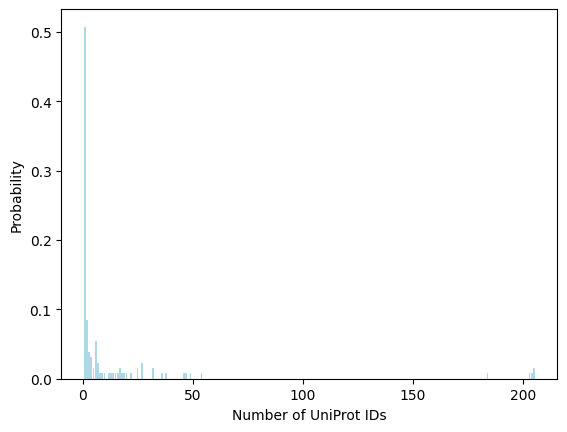

In [69]:
pdb_counts_series = pd.Series(pdb_occurrences)
counts = pdb_counts_series.value_counts().sort_index()
prob = counts / counts.sum()

plt.bar(prob.index, prob.values, color='lightblue')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Probability')

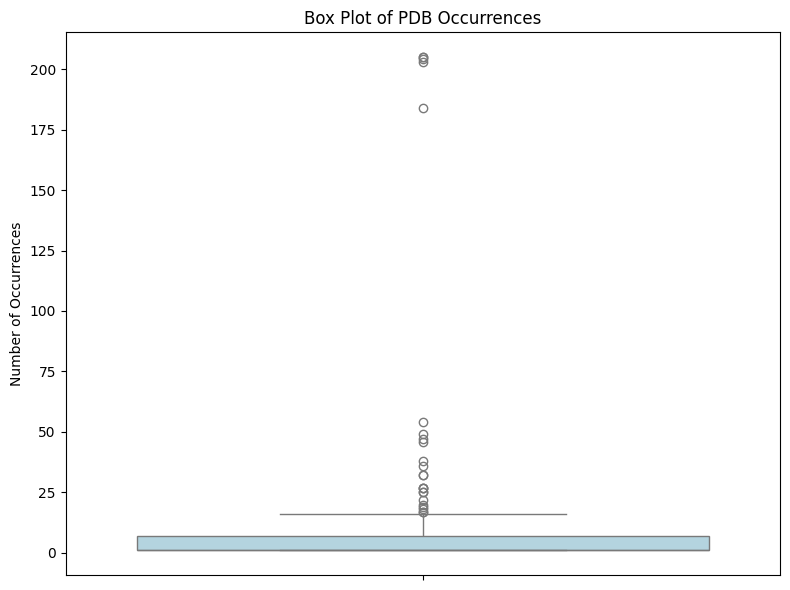

In [70]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=pdb_counts_series.values, color='lightblue')
plt.title('Box Plot of PDB Occurrences')
plt.ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

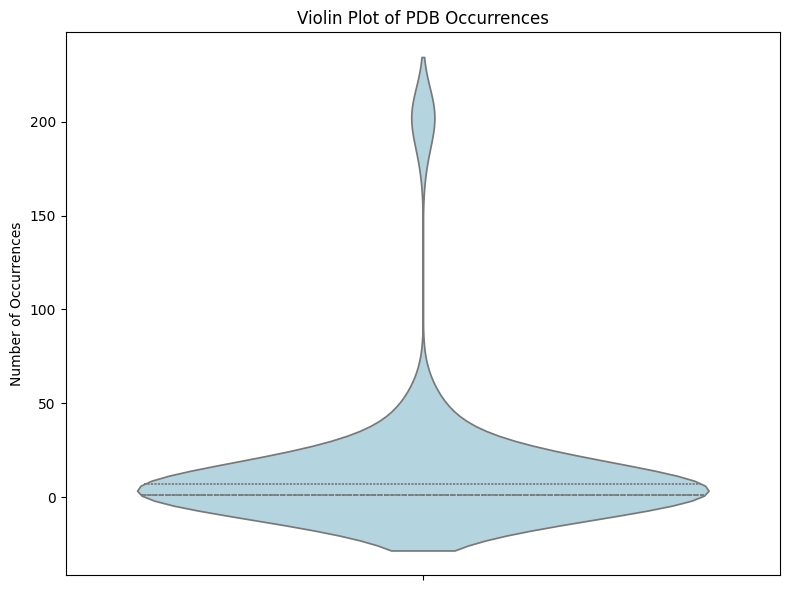

In [71]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=pdb_counts_series.values, inner='quartile', color='lightblue')
plt.title('Violin Plot of PDB Occurrences')
plt.ylabel('Number of Occurrences')
plt.tight_layout()
plt.show()

### Retrieving monomers:
1. Extract the list of PDB id
2. Do mapping from Uniprot
3. Download TSV
4. Load tsv on this notebook

In [72]:
for key in pdb_occurrences:
  print(key)

1CHO
1R0R
3SGB
1PPF
1A22
1GC1
1BRS
1JTG
1EMV
2WPT
1IAR
1A4Y
1CBW
3NPS
1KTZ
1EAW
2G2U
3BN9
1TM1
2FTL
1LFD
1XD3
1FFW
1Z7X
2J0T
1AK4
1FC2
3BK3
1F47
2SIC
1MAH
4CPA
1GCQ
2O3B
1FCC
1CSE
1ACB
1H9D
2PCB
1S1Q
1E96
2PCC
2I9B
1UUZ
1SMF
2GOX
2BTF
2AJF
1N8O
2J1K
2HRK
2B42
2C0L
3D5S
1B2S
1KAC
1FY8
1B3S
2OOB
3D5R
1B2U
1EFN
3BP8
2HLE
1M9E
1X1X
2A9K
2B12
2B11
2VLO
1FR2
2GYK
2B0Z
2B10
2VLP
2VLN
2VLQ
1Y33
1Y1K
1X1W
1SIB
1SBN
1TO1
1TMG
1TM7
1TM3
1TM5
1TM4
1Y3D
1Y48
1Y3C
1Y3B
1Y34
1GRN
1S0W
1REW
1GL1
1HE8
2G2W
1GL0
3TGK
1F5R
3BTF
3BTG
3BTD
3BTE
3BTQ
3BTW
3BTT
2SGP
1CSO
1CT0
3BTH
3BTM
1CT4
1CT2
2SGQ
1SGD
1SGP
1SGQ
1SGE
1SGN
2NU0
1SGY
2NU1
2NU2
2J12
2NU4
1P69
1P6A


In [73]:
filepath = '/content/drive/MyDrive/Mapping_probass.xlsx'
try:
    df_mapping = pd.read_excel(filepath)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [74]:
df_mapping

,From,Entry
0,1CHO,P68390
1,1CHO,P00766
2,1R0R,P00780
3,1R0R,P68390
4,3SGB,P00777
...,...,...
257,2NU4,P68436
258,1P69,P36711
259,1P69,P78310
260,1P6A,P36711


In [75]:
from_entry_dict = df_mapping.groupby('From')['Entry'].apply(list).to_dict()
print(from_entry_dict)

{1000000000000000049861653971908893017010268485438462151574892930611988399099305815384459015356416: ['P19878', 'P63000'], '1,00 SGD': ['P00777', 'P68390'], '1A22': ['P01241', 'P10912'], '1A4Y': ['P03950', 'P13489'], '1ACB': ['P01051', 'P00766'], '1AK4': ['P12497', 'P62937'], '1B2S': ['P00648', 'P11540'], '1B2U': ['P00648', 'P11540'], '1B3S': ['P00648', 'P11540'], '1BRS': ['P00648', 'P11540'], '1CBW': ['P00766', 'P00767', 'P00974'], '1CHO': ['P68390', 'P00766'], '1CSE': ['P00780', 'P01051'], '1CSO': ['P00777', 'P68390'], '1CT0': ['P00777', 'P68390'], '1CT2': ['P00777', 'P68390'], '1CT4': ['P00777', 'P68390'], '1EAW': ['Q9Y5Y6', 'P00974'], '1EFN': ['P03406', 'P06241'], '1EMV': ['P09883', 'P13479'], '1F47': ['P0A9A6', 'P77173'], '1F5R': ['P00763', 'P00974'], '1FC2': ['P38507', 'P01857'], '1FCC': ['P19909', 'P01857'], '1FFW': ['P07363', 'P0AE67'], '1FR2': ['P09883', 'P13479'], '1FY8': ['P00763', 'P00974'], '1GC1': ['P04578', 'P01730'], '1GCQ': ['P27870', 'P62993'], '1GL0': ['P80060', 'P007

In [76]:
df_drive['uniprot'] = df_drive['PDB'].map(from_entry_dict)
display(df_drive.head())

,Skempi,Mutation,Experimental_ddg,PDB,uniprot
0,1CSE_E_I,LI38G,2.271139,1CSE,"[P00780, P01051]"
1,1CSE_E_I,LI38S,1.183856,1CSE,"[P00780, P01051]"
2,1CSE_E_I,LI38P,6.737446,1CSE,"[P00780, P01051]"
3,1CSE_E_I,LI38I,2.970158,1CSE,"[P00780, P01051]"
4,1CSE_E_I,LI38D,4.393584,1CSE,"[P00780, P01051]"


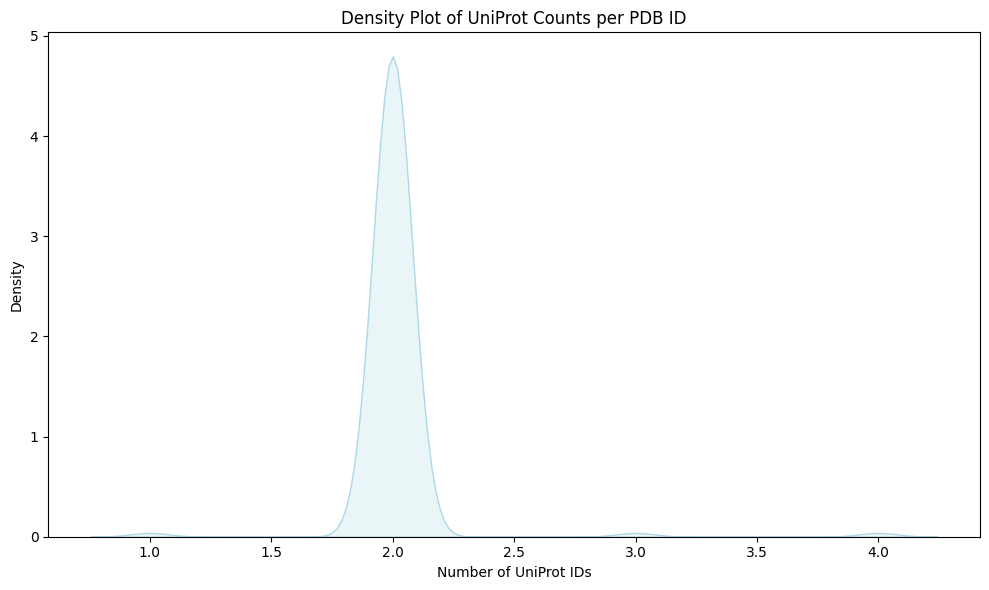

In [77]:
proteins_compl = {}
for key in from_entry_dict:
  proteins_compl[key]=len(from_entry_dict[key])

uniprot_counts_series = pd.Series(proteins_compl)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

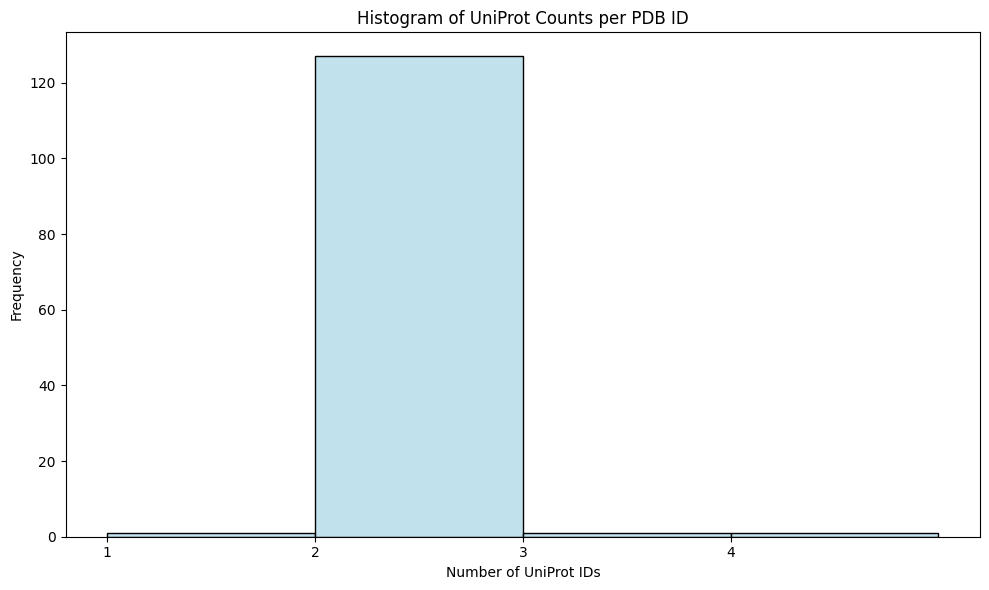

In [78]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

In [79]:
min_uniprot_count = min(proteins_compl.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")

The minimum number of UniProt IDs associated with a PDB ID is: 1


In [80]:
max_uniprot_count = max(proteins_compl.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")

The maximum number of UniProt IDs associated with a PDB ID is: 4


In [81]:
prot_per_complex = {}

In [82]:
pdb_1_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_1_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_1_uniprot:
    print(pdb_id)
prot_per_complex[1]=len(pdb_1_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
3NPS


In [83]:
pdb_2_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 2]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_2_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_2_uniprot:
    print(pdb_id)
prot_per_complex[2]=len(pdb_2_uniprot)

Number of PDB IDs with exactly one UniProt ID: 127
PDB IDs with exactly one UniProt ID:
1000000000000000049861653971908893017010268485438462151574892930611988399099305815384459015356416
1,00 SGD
1A22
1A4Y
1ACB
1AK4
1B2S
1B2U
1B3S
1BRS
1CHO
1CSE
1CSO
1CT0
1CT2
1CT4
1EAW
1EFN
1EMV
1F47
1F5R
1FC2
1FCC
1FFW
1FR2
1FY8
1GC1
1GCQ
1GL0
1GL1
1GRN
1H9D
1HE8
1IAR
1JTG
1KAC
1KTZ
1LFD
1M9E
1MAH
1N8O
1P69
1P6A
1PPF
1R0R
1REW
1S0W
1S1Q
1SBN
1SGE
1SGN
1SGP
1SGQ
1SGY
1SIB
1SMF
1TM1
1TM3
1TM4
1TM5
1TM7
1TMG
1TO1
1UUZ
1X1W
1X1X
1XD3
1Y1K
1Y33
1Y34
1Y3B
1Y3C
1Y3D
1Y48
1Z7X
2,00 HRK
2A9K
2AJF
2B0Z
2B10
2B11
2B12
2B42
2BTF
2C0L
2FTL
2G2U
2G2W
2GOX
2GYK
2HLE
2I9B
2J0T
2J12
2J1K
2NU0
2NU1
2NU2
2NU4
2O3B
2OOB
2PCB
2PCC
2SGP
2SGQ
2SIC
2VLN
2VLO
2VLP
2VLQ
2WPT
3BK3
3BP8
3BTD
3BTE
3BTF
3BTG
3BTH
3BTM
3BTQ
3BTT
3BTW
3D5R
3D5S
3SGB
3TGK
4CPA


In [84]:
pdb_3_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 3]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_3_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_3_uniprot:
    print(pdb_id)
prot_per_complex[3]=len(pdb_3_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
1CBW


In [85]:
pdb_4_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 4]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_4_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_4_uniprot:
    print(pdb_id)
prot_per_complex[4]=len(pdb_4_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
3BN9


In [86]:
print("The dataset counts a total of: "+str(prot_per_complex[1]*1+prot_per_complex[2]*2+prot_per_complex[3]*3+prot_per_complex[4]*4)+" proteins (or Uniprot IDs)")

The dataset counts a total of: 262 proteins (or Uniprot IDs)
